# Notebook 2 - Inverse dynamica, onbalans en actuatoranalyse

Deze notebook voert de inverse dynamica uit van het paraplu-stangenmechanisme. De kinematica wordt ingeladen uit `notebook1_kinematica_results.npz`, het overdrachtsbestand uit `Notebook 1 - Examen.ipynb`. Daardoor blijven positie, snelheid, versnelling, dynamica en actuatoranalyse gekoppeld aan dezelfde geometrie en hetzelfde schuivertraject.

De analyse volgt de lesaanpak voor vlakke mechanismen. Per bewegende link worden drie Newton-Euler vergelijkingen opgesteld:

$$
\sum F_x = m a_x,\qquad \sum F_y = m a_y,\qquad \sum M_{cg} = J_{cg}\alpha.
$$

Alle vergelijkingen worden per tijdstap samengebracht in `A w = b`. De onbekenden `w` zijn de aandrijfkracht, de frame-reacties en de interne gewrichtskrachten. Dit is inverse dynamica: de beweging is gekend, de krachten worden berekend. Voorwaartse dynamica wordt niet uitgevoerd.

Zwaartekracht, windbelasting en wrijving worden in deze versie nog niet meegenomen. Daardoor is de houdkracht in de open stand binnen dit model nul zodra de schuiver stilstaat. In een echte paraplu komt de houdkracht vooral van externe belastingen en van de manier waarop de actuator of structuur de positie vergrendelt. Daarom focust deze notebook op een lineaire actuator, schroefspindel of servo-oplossing.

## Setup en data uit Notebook 1

Notebook 2 verwacht dezelfde kinematische keys als de opslagcel van Notebook 1: tijd, schuiverpositie, schuiversnelheid, schuiverversnelling, linkhoeken, hoeksnelheden, hoekversnellingen, beweging van punt `K`, conditionering, sluitingsfout en geometrische parameters. Als een parameter in Notebook 1 aangepast wordt, moet Notebook 1 eerst opnieuw volledig uitgevoerd worden.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

kinematics_path = Path("notebook1_kinematica_results.npz")
if not kinematics_path.exists():
    raise FileNotFoundError("Run eerst 'Notebook 1 - Examen.ipynb' zodat notebook1_kinematica_results.npz bestaat.")

required_keys = [
    "t", "Ts", "s", "ds", "dds",
    "theta3", "theta4", "theta5", "theta6", "theta7", "theta8",
    "dtheta3", "dtheta4", "dtheta5", "dtheta6", "dtheta7", "dtheta8",
    "ddtheta3", "ddtheta4", "ddtheta5", "ddtheta6", "ddtheta7", "ddtheta8",
    "Kx", "Ky", "Kdot_x", "Kdot_y", "Kdot_norm", "Kddot_x", "Kddot_y", "Kddot_norm",
    "cond", "residual_pos",
    "L1", "r3a", "r3b", "r4a", "r4b", "r5a", "r5b", "r6", "r7a", "r7b", "r8a", "r8b",
]
data = np.load(kinematics_path)
missing = [key for key in required_keys if key not in data.files]
if missing:
    raise KeyError(f"Ontbrekende keys in {kinematics_path}: {missing}")

t = data["t"]; Ts = float(data["Ts"]); s = data["s"]; ds = data["ds"]; dds = data["dds"]
theta3 = data["theta3"]; theta4 = data["theta4"]; theta5 = data["theta5"]
theta6 = data["theta6"]; theta7 = data["theta7"]; theta8 = data["theta8"]
dtheta3 = data["dtheta3"]; dtheta4 = data["dtheta4"]; dtheta5 = data["dtheta5"]
dtheta6 = data["dtheta6"]; dtheta7 = data["dtheta7"]; dtheta8 = data["dtheta8"]
ddtheta3 = data["ddtheta3"]; ddtheta4 = data["ddtheta4"]; ddtheta5 = data["ddtheta5"]
ddtheta6 = data["ddtheta6"]; ddtheta7 = data["ddtheta7"]; ddtheta8 = data["ddtheta8"]
Kx = data["Kx"]; Ky = data["Ky"]; Kdot_x = data["Kdot_x"]; Kdot_y = data["Kdot_y"]
Kdot_norm = data["Kdot_norm"]; Kddot_x = data["Kddot_x"]; Kddot_y = data["Kddot_y"]; Kddot_norm = data["Kddot_norm"]
cond = data["cond"]; residual_pos = data["residual_pos"]
L1 = float(data["L1"]); r3a = float(data["r3a"]); r3b = float(data["r3b"])
r4a = float(data["r4a"]); r4b = float(data["r4b"]); r5a = float(data["r5a"]); r5b = float(data["r5b"])
r6 = float(data["r6"]); r7a = float(data["r7a"]); r7b = float(data["r7b"]); r8a = float(data["r8a"]); r8b = float(data["r8b"])

n_steps = len(t)
T_cycle = float(t[-1] - t[0])
if T_cycle <= 0:
    raise ValueError("De tijdvector uit Notebook 1 heeft geen positieve cyclusduur.")

print("Kinematische data ingeladen uit:")
print(kinematics_path.resolve())
print(f"Aantal tijdstappen: {n_steps}")
print(f"Cyclusduur: {T_cycle:.4f} s")
print(f"Maximale sluitingsfout uit Notebook 1: {np.max(residual_pos):.3e}")

Kinematische data ingeladen uit:
C:\Users\WELL_ASUS_BUP\OneDrive\Alexandre\KUL\Semester 6\Beweging\Bewegingen-trillingen-project\project\notebooks\Stangen\notebook1_kinematica_results.npz
Aantal tijdstappen: 241
Cyclusduur: 12.0000 s
Maximale sluitingsfout uit Notebook 1: 5.463e-13


## Dynamische parameters

De massa van de schuiver wordt apart gekozen. De massa's van de stangen worden standaard uit een uniforme lijnmassa berekend, zodat langere stangen automatisch zwaarder worden. De traagheidsmomenten volgen uit de slanke-staafformule `J = m L^2 / 12`. Als later echte massa's beschikbaar zijn, kunnen ze hier rechtstreeks ingevuld worden.

De aandrijving wordt gemodelleerd als een gecontroleerde lineaire actuator of als een roterende servomotor met schroefspindel. De schuiver moet naar een stand bewegen en daarna kunnen blijven staan. Deze notebook bepaalt de inertiele bewegingsbelasting: lineaire kracht, schuiversnelheid, actuatorvermogen, schroefkoppel en motortoerental. Statische houdlasten door zwaartekracht, wind, wrijving of elastische voorspanning worden hier niet als losse placeholder toegevoegd, omdat ze in dit model nog niet fysisch berekend worden.


In [2]:
L2 = 0.0
L3 = r3a + r3b
L4 = r4a + r4b
L5 = r5a + r5b
L6 = r6
L7 = r7a + r7b
L8 = r8a + r8b

slider_mass = 1.00          # [kg]
line_mass_density = 1.00    # [kg/m]
mass_scale = 1.0
inertia_scale = 1.0         # enkel rotatie-inertie schalen; meestal 1.0 laten

masses = {
    2: slider_mass * mass_scale,
    3: line_mass_density * L3 * mass_scale,
    4: line_mass_density * L4 * mass_scale,
    5: line_mass_density * L5 * mass_scale,
    6: line_mass_density * L6 * mass_scale,
    7: line_mass_density * L7 * mass_scale,
    8: line_mass_density * L8 * mass_scale,
}
inertias = {
    2: 0.0,
    3: masses[3] * L3**2 / 12 * inertia_scale,
    4: masses[4] * L4**2 / 12 * inertia_scale,
    5: masses[5] * L5**2 / 12 * inertia_scale,
    6: masses[6] * L6**2 / 12 * inertia_scale,
    7: masses[7] * L7**2 / 12 * inertia_scale,
    8: masses[8] * L8**2 / 12 * inertia_scale,
}

# Lineaire actuator / schroefspindel / servo
actuator_efficiency = 0.80
actuator_safety_factor = 1.50
screw_lead = 0.005                 # [m/omw] verplaatsing per motoromwenteling

print("Dynamische parameters:")
for link_id in range(2, 9):
    print(f"link {link_id}: m = {masses[link_id]:.4f} kg, J = {inertias[link_id]:.5f} kg m^2")
print()
print("Actuatorparameters:")
print(f"screw_lead = {screw_lead:.4f} m/omw")
print(f"actuator_efficiency = {actuator_efficiency:.2f}")


Dynamische parameters:
link 2: m = 1.0000 kg, J = 0.00000 kg m^2
link 3: m = 0.9359 kg, J = 0.06832 kg m^2
link 4: m = 1.5970 kg, J = 0.33944 kg m^2
link 5: m = 0.6560 kg, J = 0.02352 kg m^2
link 6: m = 0.6804 kg, J = 0.02625 kg m^2
link 7: m = 0.6804 kg, J = 0.02625 kg m^2
link 8: m = 0.9044 kg, J = 0.06164 kg m^2

Actuatorparameters:
screw_lead = 0.0050 m/omw
actuator_efficiency = 0.80


## Rigid-body kinematica

Voor de inverse dynamica zijn de posities, snelheden en versnellingen van de zwaartepunten nodig. Deze cel reconstrueert de gewrichtspunten uit Notebook 1 en gebruikt algemene rigid-body formules:

$$
\mathbf{v}_P = \mathbf{v}_O + \omega \times \mathbf{r}_{OP},\qquad
\mathbf{a}_P = \mathbf{a}_O + \alpha \times \mathbf{r}_{OP} - \omega^2\mathbf{r}_{OP}.
$$

Daardoor blijven de formules algemeen en minder foutgevoelig dan aparte componentuitdrukkingen per link.

In [3]:
def perp(v):
    v = np.asarray(v)
    return np.column_stack((-v[:, 1], v[:, 0])) if v.ndim == 2 else np.array([-v[1], v[0]])

def rigid_point(ref_pos, ref_vel, ref_acc, theta, omega, alpha, local_vector):
    local_vector = np.asarray(local_vector, dtype=float)
    r_global = np.column_stack((
        local_vector[0] * np.cos(theta) - local_vector[1] * np.sin(theta),
        local_vector[0] * np.sin(theta) + local_vector[1] * np.cos(theta),
    ))
    pos = ref_pos + r_global
    vel = ref_vel + omega[:, None] * perp(r_global)
    acc = ref_acc + alpha[:, None] * perp(r_global) - (omega[:, None] ** 2) * r_global
    return pos, vel, acc

zero = np.zeros(n_steps)
zeros2 = np.zeros((n_steps, 2))

C_pos = zeros2.copy(); C_vel = zeros2.copy(); C_acc = zeros2.copy()
B_pos = np.column_stack((zero, -s))
B_vel = np.column_stack((zero, -ds))
B_acc = np.column_stack((zero, -dds))

D_pos, D_vel, D_acc = rigid_point(B_pos, B_vel, B_acc, theta3, dtheta3, ddtheta3, [r3a, 0.0])
E3_pos, _, _ = rigid_point(B_pos, B_vel, B_acc, theta3, dtheta3, ddtheta3, [r3a + r3b, 0.0])
E4_pos, _, _ = rigid_point(C_pos, C_vel, C_acc, theta4, dtheta4, ddtheta4, [r4a, 0.0])
E_pos = 0.5 * (E3_pos + E4_pos)
H_pos, H_vel, H_acc = rigid_point(C_pos, C_vel, C_acc, theta4, dtheta4, ddtheta4, [r4a + r4b, 0.0])
F_pos, F_vel, F_acc = rigid_point(D_pos, D_vel, D_acc, theta5, dtheta5, ddtheta5, [r5a, 0.0])
G5_pos, _, _ = rigid_point(D_pos, D_vel, D_acc, theta5, dtheta5, ddtheta5, [r5a + r5b, 0.0])
G7_pos, _, _ = rigid_point(H_pos, H_vel, H_acc, theta7, dtheta7, ddtheta7, [-r7a, 0.0])
G_pos = 0.5 * (G5_pos + G7_pos)
I_pos, I_vel, I_acc = rigid_point(F_pos, F_vel, F_acc, theta6, dtheta6, ddtheta6, [r6, 0.0])
J7_pos, _, _ = rigid_point(H_pos, H_vel, H_acc, theta7, dtheta7, ddtheta7, [r7b, 0.0])
J8_pos, _, _ = rigid_point(I_pos, I_vel, I_acc, theta8, dtheta8, ddtheta8, [r8a, 0.0])
J_pos = 0.5 * (J7_pos + J8_pos)
K_pos, K_vel, K_acc = rigid_point(I_pos, I_vel, I_acc, theta8, dtheta8, ddtheta8, [r8a + r8b, 0.0])

cg_pos, cg_vel, cg_acc, alpha = {}, {}, {}, {}
cg_pos[2] = B_pos.copy(); cg_vel[2] = B_vel.copy(); cg_acc[2] = B_acc.copy(); alpha[2] = zero.copy()
cg_pos[3], cg_vel[3], cg_acc[3] = rigid_point(B_pos, B_vel, B_acc, theta3, dtheta3, ddtheta3, [L3 / 2, 0.0]); alpha[3] = ddtheta3
cg_pos[4], cg_vel[4], cg_acc[4] = rigid_point(C_pos, C_vel, C_acc, theta4, dtheta4, ddtheta4, [L4 / 2, 0.0]); alpha[4] = ddtheta4
cg_pos[5], cg_vel[5], cg_acc[5] = rigid_point(D_pos, D_vel, D_acc, theta5, dtheta5, ddtheta5, [L5 / 2, 0.0]); alpha[5] = ddtheta5
cg_pos[6], cg_vel[6], cg_acc[6] = rigid_point(F_pos, F_vel, F_acc, theta6, dtheta6, ddtheta6, [L6 / 2, 0.0]); alpha[6] = ddtheta6
cg_pos[7], cg_vel[7], cg_acc[7] = rigid_point(H_pos, H_vel, H_acc, theta7, dtheta7, ddtheta7, [(r7b - r7a) / 2, 0.0]); alpha[7] = ddtheta7
cg_pos[8], cg_vel[8], cg_acc[8] = rigid_point(I_pos, I_vel, I_acc, theta8, dtheta8, ddtheta8, [L8 / 2, 0.0]); alpha[8] = ddtheta8

K_loaded = np.column_stack((Kx, Ky))
print("Rigid-body kinematica opgebouwd.")
print(f"max |K_reconstructie - K_Notebook1| = {np.max(np.linalg.norm(K_pos - K_loaded, axis=1)):.3e} m")
print(f"max sluitverschil E/G/J = {np.max(np.linalg.norm(E3_pos - E4_pos, axis=1)):.3e} / {np.max(np.linalg.norm(G5_pos - G7_pos, axis=1)):.3e} / {np.max(np.linalg.norm(J7_pos - J8_pos, axis=1)):.3e} m")

Rigid-body kinematica opgebouwd.
max |K_reconstructie - K_Notebook1| = 4.475e-16 m
max sluitverschil E/G/J = 5.463e-13 / 5.476e-13 / 5.476e-13 m


## Inverse dynamica

De onbekenden zijn de externe frame-/actuatorkrachten en de interne gewrichtskrachten. De tekenconventie is consequent: een onbekende kracht wordt positief gekozen op een link en komt met tegengesteld teken terug op de verbonden link. De schuiver heeft een horizontale geleidingsreactie `R_Ax`, een verticale actuatorkracht `F_act_y` en een eventueel geleidingsmoment `M_A`.

In [4]:
unknown_labels = [
    "R_Ax", "F_act_y", "M_A", "C_x", "C_y", "B_x", "B_y", "D_x", "D_y", "E_x", "E_y",
    "F_x", "F_y", "G_x", "G_y", "H_x", "H_y", "I_x", "I_y", "J_x", "J_y",
]
unknown_index = {name: i for i, name in enumerate(unknown_labels)}
n_unknowns = len(unknown_labels)

def moment_2d(r, F):
    return r[0] * F[1] - r[1] * F[0]

def add_link_equations(A, b, row, m, J, a_cg, alpha_cg, cg, forces, moments=None):
    moments = moments or []
    row_fx, row_fy, row_m = row, row + 1, row + 2
    for fx_name, fy_name, sign, point in forces:
        r = point - cg
        if fx_name is not None:
            j = unknown_index[fx_name]
            A[row_fx, j] += sign
            A[row_m, j] += -sign * r[1]
        if fy_name is not None:
            j = unknown_index[fy_name]
            A[row_fy, j] += sign
            A[row_m, j] += sign * r[0]
    for moment_name, sign in moments:
        A[row_m, unknown_index[moment_name]] += sign
    b[row_fx] = m * a_cg[0]
    b[row_fy] = m * a_cg[1]
    b[row_m] = J * alpha_cg
    return row + 3

def build_inverse_dynamics_system(k, masses_local=None, inertias_local=None):
    masses_local = masses if masses_local is None else masses_local
    inertias_local = inertias if inertias_local is None else inertias_local
    A = np.zeros((n_unknowns, n_unknowns))
    b = np.zeros(n_unknowns)
    row = 0
    row = add_link_equations(A, b, row, masses_local[2], inertias_local[2], cg_acc[2][k], alpha[2][k], cg_pos[2][k],
                             [("R_Ax", None, 1.0, B_pos[k]), (None, "F_act_y", 1.0, B_pos[k]), ("B_x", "B_y", 1.0, B_pos[k])],
                             [("M_A", 1.0)])
    row = add_link_equations(A, b, row, masses_local[3], inertias_local[3], cg_acc[3][k], alpha[3][k], cg_pos[3][k],
                             [("B_x", "B_y", -1.0, B_pos[k]), ("D_x", "D_y", 1.0, D_pos[k]), ("E_x", "E_y", 1.0, E_pos[k])])
    row = add_link_equations(A, b, row, masses_local[4], inertias_local[4], cg_acc[4][k], alpha[4][k], cg_pos[4][k],
                             [("C_x", "C_y", 1.0, C_pos[k]), ("E_x", "E_y", -1.0, E_pos[k]), ("H_x", "H_y", 1.0, H_pos[k])])
    row = add_link_equations(A, b, row, masses_local[5], inertias_local[5], cg_acc[5][k], alpha[5][k], cg_pos[5][k],
                             [("D_x", "D_y", -1.0, D_pos[k]), ("F_x", "F_y", 1.0, F_pos[k]), ("G_x", "G_y", 1.0, G_pos[k])])
    row = add_link_equations(A, b, row, masses_local[6], inertias_local[6], cg_acc[6][k], alpha[6][k], cg_pos[6][k],
                             [("F_x", "F_y", -1.0, F_pos[k]), ("I_x", "I_y", 1.0, I_pos[k])])
    row = add_link_equations(A, b, row, masses_local[7], inertias_local[7], cg_acc[7][k], alpha[7][k], cg_pos[7][k],
                             [("G_x", "G_y", -1.0, G_pos[k]), ("H_x", "H_y", -1.0, H_pos[k]), ("J_x", "J_y", 1.0, J_pos[k])])
    row = add_link_equations(A, b, row, masses_local[8], inertias_local[8], cg_acc[8][k], alpha[8][k], cg_pos[8][k],
                             [("I_x", "I_y", -1.0, I_pos[k]), ("J_x", "J_y", -1.0, J_pos[k])])
    if row != n_unknowns:
        raise RuntimeError(f"Verkeerd aantal vergelijkingen: {row} i.p.v. {n_unknowns}")
    return A, b

A_all = np.zeros((n_steps, n_unknowns, n_unknowns))
b_all = np.zeros((n_steps, n_unknowns))
w_all = np.zeros((n_steps, n_unknowns))
dyn_residual = np.zeros(n_steps)
dyn_cond = np.zeros(n_steps)
for k in range(n_steps):
    A_k, b_k = build_inverse_dynamics_system(k)
    A_all[k] = A_k; b_all[k] = b_k
    dyn_cond[k] = np.linalg.cond(A_k)
    w_all[k] = np.linalg.solve(A_k, b_k)
    dyn_residual[k] = np.linalg.norm(A_k @ w_all[k] - b_k)

for name, idx in unknown_index.items():
    globals()[name] = w_all[:, idx]
F_actuator_y = F_act_y
F_drive_s = -F_actuator_y
M_guide_A = M_A

print("Inverse dynamica opgelost over het volledige bewegingsbereik.")
print(f"Maximum residu ||A w - b|| = {np.max(dyn_residual):.3e}")
print(f"Gemiddeld residu           = {np.mean(dyn_residual):.3e}")
print(f"cond(A_dyn) min/gem/max    = {np.min(dyn_cond):.3e} / {np.mean(dyn_cond):.3e} / {np.max(dyn_cond):.3e}")
print(f"max |F_drive_s|            = {np.max(np.abs(F_drive_s)):.3f} N")

Inverse dynamica opgelost over het volledige bewegingsbereik.
Maximum residu ||A w - b|| = 1.242e-14
Gemiddeld residu           = 2.243e-16
cond(A_dyn) min/gem/max    = 1.878e+01 / 8.487e+01 / 2.167e+02
max |F_drive_s|            = 144.445 N


## Controle van de dynamische oplossing

Als alle bewegende links samen als een systeem beschouwd worden, vallen alle interne gewrichtskrachten weg. De som van de externe frame- en actuatorkrachten moet gelijk zijn aan de totale inertiele resultante van alle bewegende links. Hetzelfde geldt voor het moment rond punt `C`.

In [5]:
F_A_on_mechanism = np.column_stack((R_Ax, F_actuator_y))
F_C_on_mechanism = np.column_stack((C_x, C_y))
F_external_total = F_A_on_mechanism + F_C_on_mechanism
F_inertia_total = np.zeros((n_steps, 2))
M_inertia_about_C = np.zeros(n_steps)
M_external_about_C = np.zeros(n_steps)
for k in range(n_steps):
    for link_id in range(2, 9):
        F_i = masses[link_id] * cg_acc[link_id][k]
        F_inertia_total[k] += F_i
        M_inertia_about_C[k] += moment_2d(cg_pos[link_id][k] - C_pos[k], F_i) + inertias[link_id] * alpha[link_id][k]
    M_external_about_C[k] = M_guide_A[k] + moment_2d(B_pos[k] - C_pos[k], F_A_on_mechanism[k])

force_balance_error = np.linalg.norm(F_external_total - F_inertia_total, axis=1)
moment_balance_error = np.abs(M_external_about_C - M_inertia_about_C)
print("Globale dynamische controle:")
print(f"max ||F_ext - som m a_cg||       = {np.max(force_balance_error):.3e} N")
print(f"max |M_ext,C - M_inertie,C|   = {np.max(moment_balance_error):.3e} Nm")
print(f"max |M_A|                     = {np.max(np.abs(M_guide_A)):.3e} Nm")

Globale dynamische controle:
max ||F_ext - som m a_cg||       = 2.294e-14 N
max |M_ext,C - M_inertie,C|   = 1.776e-15 Nm
max |M_A|                     = 0.000e+00 Nm


## Krachten en onbalans

`F_actuator_y` is de verticale kracht van de actuator op de schuiver in het globale assenstelsel. Omdat de schuivercoordinaat `s` positief naar beneden gekozen is, is de gegeneraliseerde aandrijfkracht in positieve `s`-richting `F_drive_s = -F_actuator_y`.

De onbalansgrootheden zijn de kracht en het moment die het mechanisme op het frame uitoefent:

$$
\mathbf{F}_{shak}=-(\mathbf{F}_A+\mathbf{F}_C),\qquad
M_{shak,C}=-(M_A+\mathbf{r}_{CA}\times\mathbf{F}_A).
$$

Kernwaarden krachten en onbalans:
max |F_drive_s|   = 144.445 N
max |R_C|         = 143.830 N
max |R_A|         = 144.600 N
max |R_E|         = 132.238 N
max |F_shak|      = 9.071 N
max |M_shak,C|    = 12.515 Nm


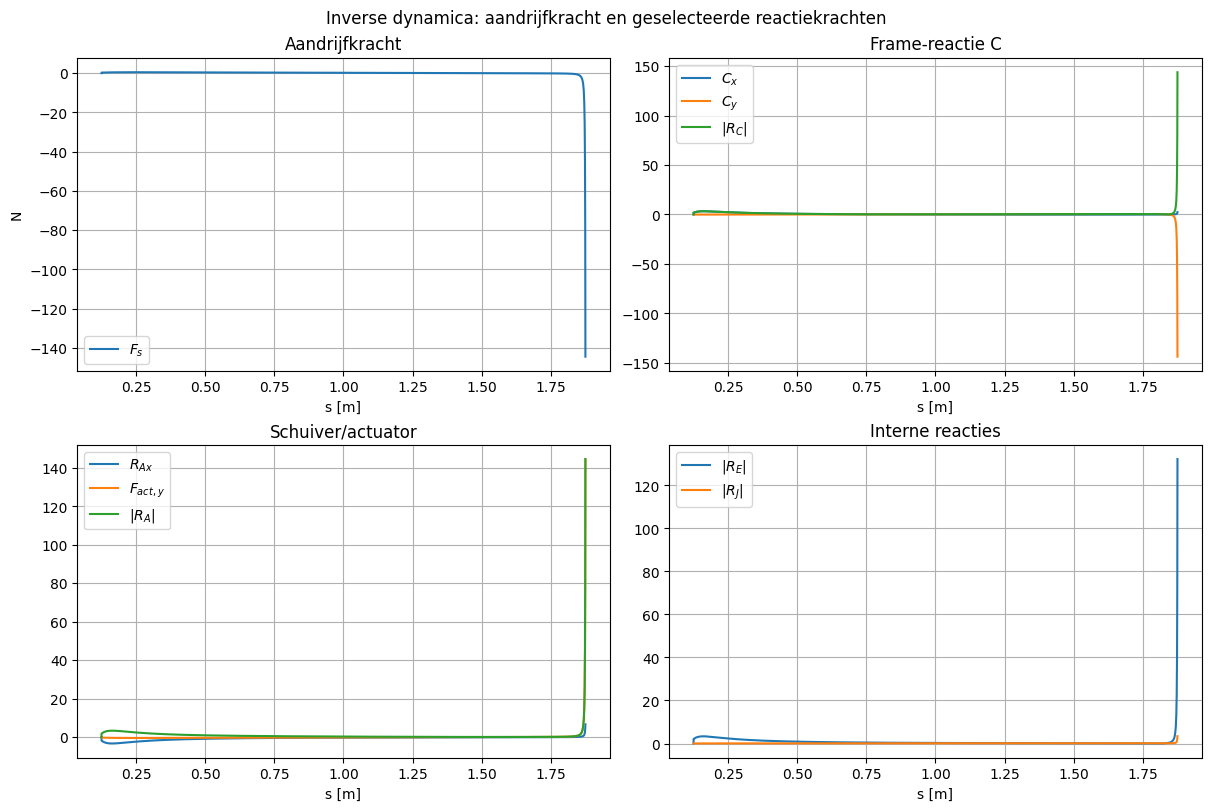

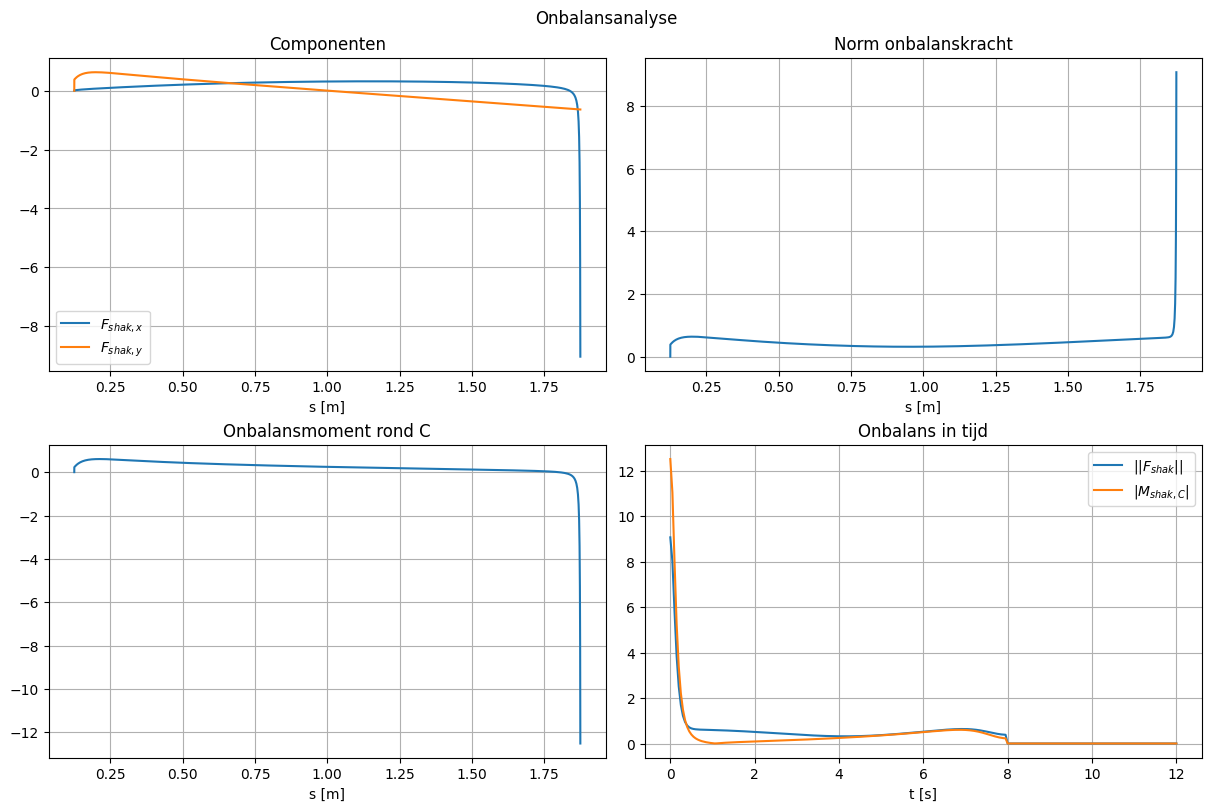

In [6]:
R_C_norm = np.linalg.norm(np.column_stack((C_x, C_y)), axis=1)
R_A_norm = np.linalg.norm(F_A_on_mechanism, axis=1)
R_E_norm = np.linalg.norm(np.column_stack((E_x, E_y)), axis=1)
R_J_norm = np.linalg.norm(np.column_stack((J_x, J_y)), axis=1)
F_shak = -F_external_total
F_shak_x = F_shak[:, 0]; F_shak_y = F_shak[:, 1]
F_shak_norm = np.linalg.norm(F_shak, axis=1)
M_shak_C = -M_external_about_C

print("Kernwaarden krachten en onbalans:")
print(f"max |F_drive_s|   = {np.max(np.abs(F_drive_s)):.3f} N")
print(f"max |R_C|         = {np.max(R_C_norm):.3f} N")
print(f"max |R_A|         = {np.max(R_A_norm):.3f} N")
print(f"max |R_E|         = {np.max(R_E_norm):.3f} N")
print(f"max |F_shak|      = {np.max(F_shak_norm):.3f} N")
print(f"max |M_shak,C|    = {np.max(np.abs(M_shak_C)):.3f} Nm")

fig_force, ax_force = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
fig_force.suptitle("Inverse dynamica: aandrijfkracht en geselecteerde reactiekrachten")
ax_force[0, 0].plot(s, F_drive_s, label=r"$F_s$"); ax_force[0, 0].set_title("Aandrijfkracht"); ax_force[0, 0].set_xlabel("s [m]"); ax_force[0, 0].set_ylabel("N"); ax_force[0, 0].grid(True); ax_force[0, 0].legend()
ax_force[0, 1].plot(s, C_x, label=r"$C_x$"); ax_force[0, 1].plot(s, C_y, label=r"$C_y$"); ax_force[0, 1].plot(s, R_C_norm, label=r"$|R_C|$"); ax_force[0, 1].set_title("Frame-reactie C"); ax_force[0, 1].set_xlabel("s [m]"); ax_force[0, 1].grid(True); ax_force[0, 1].legend()
ax_force[1, 0].plot(s, R_Ax, label=r"$R_{Ax}$"); ax_force[1, 0].plot(s, F_actuator_y, label=r"$F_{act,y}$"); ax_force[1, 0].plot(s, R_A_norm, label=r"$|R_A|$"); ax_force[1, 0].set_title("Schuiver/actuator"); ax_force[1, 0].set_xlabel("s [m]"); ax_force[1, 0].grid(True); ax_force[1, 0].legend()
ax_force[1, 1].plot(s, R_E_norm, label=r"$|R_E|$"); ax_force[1, 1].plot(s, R_J_norm, label=r"$|R_J|$"); ax_force[1, 1].set_title("Interne reacties"); ax_force[1, 1].set_xlabel("s [m]"); ax_force[1, 1].grid(True); ax_force[1, 1].legend()
plt.show()

fig_shak, ax_shak = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
fig_shak.suptitle("Onbalansanalyse")
ax_shak[0, 0].plot(s, F_shak_x, label=r"$F_{shak,x}$"); ax_shak[0, 0].plot(s, F_shak_y, label=r"$F_{shak,y}$"); ax_shak[0, 0].set_title("Componenten"); ax_shak[0, 0].set_xlabel("s [m]"); ax_shak[0, 0].grid(True); ax_shak[0, 0].legend()
ax_shak[0, 1].plot(s, F_shak_norm); ax_shak[0, 1].set_title("Norm onbalanskracht"); ax_shak[0, 1].set_xlabel("s [m]"); ax_shak[0, 1].grid(True)
ax_shak[1, 0].plot(s, M_shak_C); ax_shak[1, 0].set_title("Onbalansmoment rond C"); ax_shak[1, 0].set_xlabel("s [m]"); ax_shak[1, 0].grid(True)
ax_shak[1, 1].plot(t, F_shak_norm, label=r"$||F_{shak}||$"); ax_shak[1, 1].plot(t, np.abs(M_shak_C), label=r"$|M_{shak,C}|$"); ax_shak[1, 1].set_title("Onbalans in tijd"); ax_shak[1, 1].set_xlabel("t [s]"); ax_shak[1, 1].grid(True); ax_shak[1, 1].legend()
plt.show()

## Actuatorvermogen en schroefspindel

Dit paraplu-mechanisme is geen continu periodieke productiemachine, maar een positioneermechanisme. De schuiver moet gecontroleerd naar open, gesloten of een tussenstand kunnen bewegen en daarna stil blijven staan.

De relevante aandrijfanalyse tijdens de beweging is lineair:

$$
P_{act} = F_s \dot{s}.
$$

`F_s` is de gegeneraliseerde kracht in positieve schuiverrichting. Tijdens bewegen bepaalt deze kracht het dynamische actuatorvermogen. De dynamische kracht wordt bepaald wanneer de schuiver snelheid of versnelling heeft. Een echte hold-fase betekent hier tegelijk `ds = 0` en `dds = 0`.

Omdat deze notebook alleen de inertiele dynamica bevat, is de kracht in een echte stilstandsfase nul. Dat betekent niet dat een echte paraplu geen vergrendeling nodig heeft; het betekent alleen dat zwaartekracht, wind, wrijving en elastische voorspanning niet in deze berekening zitten. Die horen in een aparte uitbreiding waarin die belastingen expliciet gemodelleerd worden.


Actuatoranalyse:
piek dynamische schuifkracht        = 144.445 N
RMS dynamische schuifkracht         = 16.830 N
inertiele kracht in echte hold-fase = 0.000e+00 N
max positieve actuatorvermogen      = 2.019 W
max rem/regeneratief vermogen       = 0.121 W
netto energie over volledige run    = -4.1284e-03 J

Schroefspindel / servomotor sizing:
piek motortoerental                 = 4123.3 rpm
piek motorkoppel                    = 0.2155 Nm
RMS motorkoppel tijdens bewegen     = 0.0251 Nm


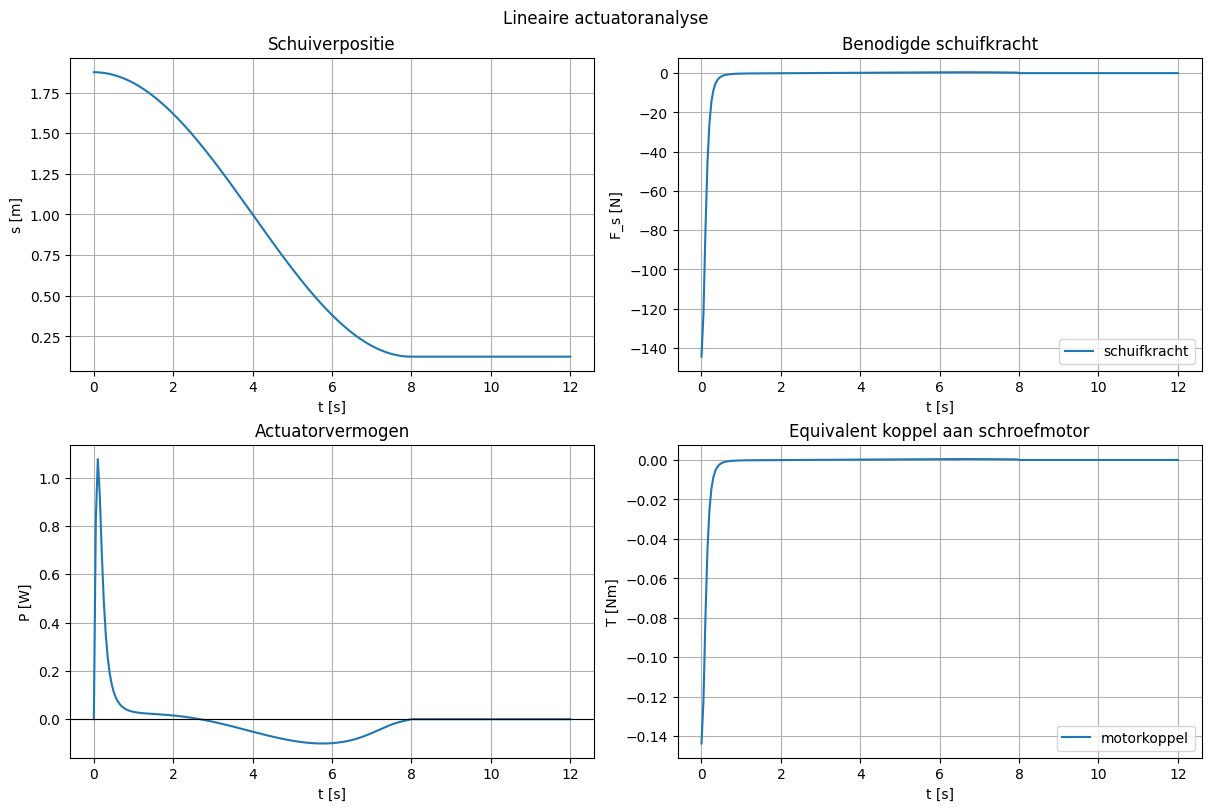

In [7]:
# ----------------------------------------------------------
# Dynamische actuatorgrootheden
# ----------------------------------------------------------
F_required_s = F_drive_s.copy()
P_act = F_required_s * ds

E_act = np.zeros_like(t)
E_act[1:] = np.cumsum(0.5 * (P_act[1:] + P_act[:-1]) * np.diff(t))
net_energy_cycle = E_act[-1] - E_act[0]
energy_fluctuation_act = np.max(E_act) - np.min(E_act)

motion_v_tol = 1e-8
motion_a_tol = 1e-8
active_motion_mask = (np.abs(ds) > motion_v_tol) | (np.abs(dds) > motion_a_tol)
hold_mask_dyn = (np.abs(ds) <= motion_v_tol) & (np.abs(dds) <= motion_a_tol)
if not np.any(active_motion_mask):
    active_motion_mask = ~hold_mask_dyn
if not np.any(hold_mask_dyn):
    hold_mask_dyn = np.zeros_like(ds, dtype=bool)
    hold_mask_dyn[np.argmin(np.abs(ds) + np.abs(dds))] = True

F_dynamic_peak = np.max(np.abs(F_required_s[active_motion_mask])) if np.any(active_motion_mask) else 0.0
F_dynamic_rms = np.sqrt(np.mean(F_required_s[active_motion_mask]**2)) if np.any(active_motion_mask) else 0.0
F_inertial_hold_peak = np.max(np.abs(F_required_s[hold_mask_dyn]))

# ----------------------------------------------------------
# Schroefspindel / roterende motor equivalent
# ----------------------------------------------------------
motor_speed_rps = ds / screw_lead
motor_speed_rpm = 60.0 * motor_speed_rps
omega_motor = 2 * np.pi * motor_speed_rps

# Motorkoppel uit arbeid: F * ds = T * omega.
# Voor een eenvoudige sizing gebruiken we dezelfde efficientie voor beide richtingen.
T_motor = F_required_s * screw_lead / (2 * np.pi * actuator_efficiency)
T_motor_peak = actuator_safety_factor * np.max(np.abs(T_motor))
T_motor_rms = actuator_safety_factor * np.sqrt(np.mean(T_motor[active_motion_mask]**2)) if np.any(active_motion_mask) else 0.0
motor_speed_peak_rpm = np.max(np.abs(motor_speed_rpm))
P_positive = np.maximum(P_act, 0.0)
P_negative = np.minimum(P_act, 0.0)
P_positive_peak = actuator_safety_factor * np.max(P_positive) / actuator_efficiency
P_regen_peak = actuator_safety_factor * abs(np.min(P_negative)) * actuator_efficiency

print("Actuatoranalyse:")
print(f"piek dynamische schuifkracht        = {F_dynamic_peak:.3f} N")
print(f"RMS dynamische schuifkracht         = {F_dynamic_rms:.3f} N")
print(f"inertiele kracht in echte hold-fase = {F_inertial_hold_peak:.3e} N")
print(f"max positieve actuatorvermogen      = {P_positive_peak:.3f} W")
print(f"max rem/regeneratief vermogen       = {P_regen_peak:.3f} W")
print(f"netto energie over volledige run    = {net_energy_cycle:.4e} J")
print()
print("Schroefspindel / servomotor sizing:")
print(f"piek motortoerental                 = {motor_speed_peak_rpm:.1f} rpm")
print(f"piek motorkoppel                    = {T_motor_peak:.4f} Nm")
print(f"RMS motorkoppel tijdens bewegen     = {T_motor_rms:.4f} Nm")

fig_act, ax_act = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
fig_act.suptitle("Lineaire actuatoranalyse")
ax_act[0, 0].plot(t, s)
ax_act[0, 0].set_title("Schuiverpositie")
ax_act[0, 0].set_xlabel("t [s]")
ax_act[0, 0].set_ylabel("s [m]")
ax_act[0, 0].grid(True)

ax_act[0, 1].plot(t, F_required_s, label="schuifkracht")
ax_act[0, 1].set_title("Benodigde schuifkracht")
ax_act[0, 1].set_xlabel("t [s]")
ax_act[0, 1].set_ylabel("F_s [N]")
ax_act[0, 1].grid(True)
ax_act[0, 1].legend()

ax_act[1, 0].plot(t, P_act)
ax_act[1, 0].axhline(0.0, color="black", linewidth=0.8)
ax_act[1, 0].set_title("Actuatorvermogen")
ax_act[1, 0].set_xlabel("t [s]")
ax_act[1, 0].set_ylabel("P [W]")
ax_act[1, 0].grid(True)

ax_act[1, 1].plot(t, T_motor, label="motorkoppel")
ax_act[1, 1].set_title("Equivalent koppel aan schroefmotor")
ax_act[1, 1].set_xlabel("t [s]")
ax_act[1, 1].set_ylabel("T [Nm]")
ax_act[1, 1].grid(True)
ax_act[1, 1].legend()

plt.show()


## Opslag van dynamische resultaten

De laatste cel schrijft de belangrijkste dynamische resultaten weg naar `notebook2_dynamica_results.npz`. Dat bestand bevat de inverse-dynamicaresultaten, onbalansgrootheden en actuatorgrootheden. Het kan later dienen als startpunt voor een aparte uitbreiding met zwaartekracht, windbelasting of wrijving.


In [8]:
results_path = Path("notebook2_dynamica_results.npz").resolve()
np.savez(
    results_path,
    t=t, s=s, ds=ds, dds=dds,
    w_all=w_all, unknown_labels=np.array(unknown_labels),
    dyn_residual=dyn_residual, dyn_cond=dyn_cond,
    F_actuator_y=F_actuator_y, F_drive_s=F_drive_s, F_required_s=F_required_s,
    R_Ax=R_Ax, C_x=C_x, C_y=C_y, M_A=M_guide_A,
    F_shak_x=F_shak_x, F_shak_y=F_shak_y, F_shak_norm=F_shak_norm, M_shak_C=M_shak_C,
    P_act=P_act, E_act=E_act,
    T_motor=T_motor, motor_speed_rpm=motor_speed_rpm,
    T_motor_peak=T_motor_peak, T_motor_rms=T_motor_rms,
    P_positive_peak=P_positive_peak, P_regen_peak=P_regen_peak,
    F_dynamic_peak=F_dynamic_peak, F_dynamic_rms=F_dynamic_rms,
    F_inertial_hold_peak=F_inertial_hold_peak,
    masses=np.array([masses[i] for i in range(2, 9)]),
    inertias=np.array([inertias[i] for i in range(2, 9)]),
)

print("Dynamische resultaten opgeslagen in:")
print(results_path)
print()
print("SAMENVATTING")
print("=" * 44)
print(f"max |F_drive_s|             : {np.max(np.abs(F_drive_s)):.3f} N")
print(f"piek actuator/schuifkracht  : {F_dynamic_peak:.3f} N")
print(f"RMS actuator/schuifkracht   : {F_dynamic_rms:.3f} N")
print(f"max |F_shak|                : {np.max(F_shak_norm):.3f} N")
print(f"max |M_shak,C|              : {np.max(np.abs(M_shak_C)):.3f} Nm")
print(f"piek motorkoppel spindel    : {T_motor_peak:.4f} Nm")
print(f"RMS motorkoppel spindel     : {T_motor_rms:.4f} Nm")
print(f"piek motortoerental         : {motor_speed_peak_rpm:.1f} rpm")

Dynamische resultaten opgeslagen in:
C:\Users\WELL_ASUS_BUP\OneDrive\Alexandre\KUL\Semester 6\Beweging\Bewegingen-trillingen-project\project\notebooks\Stangen\notebook2_dynamica_results.npz

SAMENVATTING
max |F_drive_s|             : 144.445 N
piek actuator/schuifkracht  : 144.445 N
RMS actuator/schuifkracht   : 16.830 N
max |F_shak|                : 9.071 N
max |M_shak,C|              : 12.515 Nm
piek motorkoppel spindel    : 0.2155 Nm
RMS motorkoppel spindel     : 0.0251 Nm
piek motortoerental         : 4123.3 rpm
